In [56]:
import os
from pinecone import Pinecone
from dotenv import load_dotenv
from langchain_ollama import OllamaEmbeddings
import pickle
from langchain_community.retrievers import PineconeHybridSearchRetriever
import pandas as pd
import re
from tqdm.auto import tqdm
import numpy as np

In [12]:
load_dotenv()
api_key = os.getenv("PINECONE_API_KEY")

In [13]:
embeddings = OllamaEmbeddings(
    model="qwen3-embedding:8b",
    base_url=os.environ.get("OLLAMA_URL", "http://localhost:11434"),
)

In [27]:
def parse_verse_list_str(s: str):
    return [int(x) for x in re.findall(r"\d+", str(s))]

In [32]:
def parse_verse_list_str(s: str):
    return [int(x) for x in re.findall(r"\d+", str(s))]

def chunk_hits_any_ayah(chunk_meta: dict, gt_surah: int, gt_ayah_list) -> bool:
    try:
        surah = int(chunk_meta.get("surah_no"))
        a0 = int(chunk_meta.get("ayah_start"))
        a1 = int(chunk_meta.get("ayah_end"))
    except Exception:
        return False

    if surah != int(gt_surah):
        return False

    for ay in gt_ayah_list:
        if a0 <= int(ay) <= a1:
            return True
    return False


def eval_hit_at_k(
    qa_df: pd.DataFrame,
    retriever,
    k: int = 10,
    alpha: float = 0.7,
    question_col: str = "question",
    gt_surah_col: str = "surah_no",
    gt_verses_col: str = "verses",
):
    if hasattr(retriever, "top_k"):
        retriever.top_k = k
    if hasattr(retriever, "alpha"):
        retriever.alpha = alpha

    rows = []
    hits = 0

    for idx, row in tqdm(qa_df.iterrows(), total=len(qa_df), desc=f"Evaluating Hit@{k}"):
        q = str(row[question_col])
        gt_surah = int(row[gt_surah_col])
        gt_verses = parse_verse_list_str(row[gt_verses_col])

        docs = retriever.invoke(q)

        hit = False
        hit_rank = None
        hit_doc = None

        for rank, d in enumerate(docs, start=1):
            if chunk_hits_any_ayah(d.metadata, gt_surah, gt_verses):
                hit = True
                hit_rank = rank
                hit_doc = d
                break

        hits += int(hit)

        rows.append({
            "row_idx": idx,
            "question": q,
            "gt_surah": gt_surah,
            "gt_verses": gt_verses,
            "hit": hit,
            "hit_rank": hit_rank,
            "hit_doc_meta": hit_doc.metadata if hit_doc else None,
        })

    report = pd.DataFrame(rows)
    hit_at_k = hits / len(qa_df) if len(qa_df) else 0.0
    return hit_at_k, report


In [22]:
qa_df = pd.read_csv("question_answering.csv")
qa_df

,Unnamed: 0,question_en,answer_en,chapter_no,verse_list
0,0,What is the only book that is free from any do...,This is the Book of Allah . The evidence: 'Thi...,2,[1 2]
1,1,Are the fruits of paradise similar to the frui...,"Yes, and the evidence: 'And give good news to ...",2,[25]
2,2,How many deaths and how many lives do humans h...,"And you were dead, and He gave you life, then ...",2,[28]
3,3,How many heavens are there?,He it is Who created for you all that is in th...,2,[29]
4,4,"What did Adam learn from Allah , which was no...","He taught Adam the names of all things, then H...",2,[31]
...,...,...,...,...,...
1186,1218,Who is the wife of Ibrahim who laughed when s...,She is Sarah.,11,[71]
1187,1219,"Indeed, Abraham was forbearing, often turning ...","Abraham, peace be upon him, is patient, dislik...",11,[75]
1188,1220,Why did Lot grieve when the guests arrived at...,He feared for them because they were handsome-...,11,[77]
1189,1221,"What does Lut mean by his statement, 'If only...","If I had power and supporters among you, or if...",11,[80]


In [65]:
pc = Pinecone(api_key=api_key)
index_ebn = pc.Index("quran-tafseer-ebn")

In [66]:
with open("bm25_quran_ebn.pkl", "rb") as f:
    bm25_ebn = pickle.load(f)

In [67]:
NAMESPACE = "quran_jal"

retriever_jal = PineconeHybridSearchRetriever(
    embeddings=embeddings,
    sparse_encoder=bm25_ebn,
    index=index_ebn,
    namespace=NAMESPACE,
    top_k=10,
    alpha=0.7,
)

docs = retriever_jal.invoke("What does the Quran say about patience?")
print(len(docs))
print(docs[0].metadata)
print(docs[0].page_content[:400])


10
{'ayah_end': 154.0, 'ayah_start': 153.0, 'surah_no': 2.0, 'score': 0.578527093}
ayah: O believers! Seek comfort in patience and prayer. Allah is truly with those who are patient. Never say that those martyred in the cause of Allah are dead-in fact, they are alive! But you do not perceive it.
tafseer: Allah commands patience and prayer to help the servant in both bounty and calamity. If a believer receives a blessing, gratitude benefits him; if he faces hardship, patience bene


In [45]:
hit15_ebn, report = eval_hit_at_k(
    qa_df=qa_df,
    retriever=retriever_jal,
    k=15,
    alpha=0.7,
    question_col="question_en",
    gt_surah_col="chapter_no",
    gt_verses_col="verse_list",
)

print("Hit@15:", hit15_ebn)
print(report["hit"].value_counts())
report.head()


Evaluating Hit@15:   0%|          | 0/1191 [00:00<?, ?it/s]

Hit@15: 0.72544080604534
hit
True     864
False    327
Name: count, dtype: int64


,row_idx,question,gt_surah,gt_verses,hit,hit_rank,hit_doc_meta
0,0,What is the only book that is free from any do...,2,"[1, 2]",True,1.0,"{'ayah_end': 2.0, 'ayah_start': 2.0, 'surah_no..."
1,1,Are the fruits of paradise similar to the frui...,2,[25],True,1.0,"{'ayah_end': 25.0, 'ayah_start': 25.0, 'surah_..."
2,2,How many deaths and how many lives do humans h...,2,[28],False,NaN,None
3,3,How many heavens are there?,2,[29],True,6.0,"{'ayah_end': 29.0, 'ayah_start': 29.0, 'surah_..."
4,4,"What did Adam learn from Allah , which was no...",2,[31],True,1.0,"{'ayah_end': 33.0, 'ayah_start': 31.0, 'surah_..."


---

In [69]:
pc = Pinecone(api_key=api_key)
index_jal = pc.Index("quran-tafseer-jal")

In [70]:
with open("bm25_quran_jal.pkl", "rb") as f:
    bm25_jal = pickle.load(f)

In [71]:
NAMESPACE = "quran_jal"

retriever_kathir = PineconeHybridSearchRetriever(
    embeddings=embeddings,
    sparse_encoder=bm25_jal,
    index=index_jal,
    namespace=NAMESPACE,
    top_k=15,
    alpha=0.7,
)

docs = retriever_kathir.invoke("What does the Quran say about patience?")
print(len(docs))
print(docs[0].metadata)
print(docs[0].page_content[:400])


15
{'ayah_end': 153.0, 'ayah_start': 153.0, 'surah_no': 2.0, 'score': 0.632772565}
ayah: o believers! seek comfort in patience and prayer. allah is truly with those who are patient.
tafseer: o you who believe seek help regarding the hereafter through patience in obedience and afflictions and prayer he singles it out for mention on account of its frequency and its greatness; surely god is with the patient helping them.


In [52]:
hit15_jal, report = eval_hit_at_k(
    qa_df=qa_df,
    retriever=retriever_kathir,
    k=15,
    alpha=0.7,
    question_col="question_en",
    gt_surah_col="chapter_no",
    gt_verses_col="verse_list",
)

print("Hit@15:", hit15_jal)
print(report["hit"].value_counts())
report.head()


Evaluating Hit@15:   0%|          | 0/1191 [00:00<?, ?it/s]

Hit@15: 0.7439126784214946
hit
True     886
False    305
Name: count, dtype: int64


,row_idx,question,gt_surah,gt_verses,hit,hit_rank,hit_doc_meta
0,0,What is the only book that is free from any do...,2,"[1, 2]",True,1.0,"{'ayah_end': 2.0, 'ayah_start': 2.0, 'surah_no..."
1,1,Are the fruits of paradise similar to the frui...,2,[25],True,5.0,"{'ayah_end': 25.0, 'ayah_start': 25.0, 'surah_..."
2,2,How many deaths and how many lives do humans h...,2,[28],False,NaN,None
3,3,How many heavens are there?,2,[29],True,6.0,"{'ayah_end': 29.0, 'ayah_start': 29.0, 'surah_..."
4,4,"What did Adam learn from Allah , which was no...",2,[31],True,2.0,"{'ayah_end': 31.0, 'ayah_start': 31.0, 'surah_..."


---

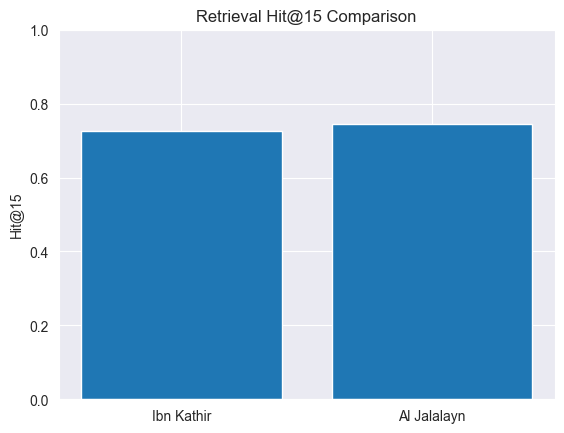

In [53]:
import matplotlib.pyplot as plt

labels = ["Ibn Kathir", "Al Jalalayn"]
values = [hit15_ebn, hit15_jal]

plt.figure()
plt.bar(labels, values)
plt.ylim(0, 1)
plt.ylabel("Hit@15")
plt.title("Retrieval Hit@15 Comparison")
plt.show()
